# MimicryDB-Auto: Statistical Analysis Pipeline

**Paper:** MimicryDB-Auto: A Curated Multi-Pathogen Dataset of Structurally Validated Pathogen-Host Peptide Pairs  

---

## Notebook Structure
1. Setup & Data Loading
2. Data Preparation
3. Core Statistical Analyses (Section 3.2)
4. Original RF Classifier — Y vs N at 2.0 Å (Section 3.3)
5. Strong vs Weak Mimic RF — within Y-class at 1.0 Å (Section 3.3 / 4.3)
6. Threshold Sensitivity Analysis (Section 3.4)
7. Figures

---
## SECTION 1: Setup & Data Loading

In [34]:
# ─────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, mannwhitneyu, norm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, recall_score, precision_score,
                             accuracy_score, classification_report,
                             confusion_matrix, roc_curve)
from matplotlib.patches import Patch

print('All libraries loaded successfully')

All libraries loaded successfully


In [35]:
# ── Load dataset ───────────────────────────────────────────────────
df = pd.read_excel('/content/ML targets (10).xlsx', sheet_name='Sheet1')
print('Shape:', df.shape)
print('\nLabel counts:')
print(df['RMSD_Mimic_Target (Y)'].value_counts())
print('\nColumns:', df.columns.tolist())

Shape: (399, 25)

Label counts:
RMSD_Mimic_Target (Y)
Y    262
N    137
Name: count, dtype: int64

Columns: ['Organism', 'Protein', 'Position', 'HLA Haplotype', 'Pathogen Peptide', 'pathogen length', '%Rank_EL(X)', 'Aff(nM)(X)', 'Immunogenicity', 'Type of MHC', 'Human_match', 'BLOSUM80 score', 'Identity percentage', 'Alignment length (Sequence)', 'Identical aa', 'Positions', 'Human Peptide', 'Human length', 'Alignment Length (Structure)', 'Structural RMSD', 'TM-align score (Human chain 2)', 'Structural alignment coverage %', 'RMSD_Mimic_Target (Y)', 'BLOSUM80_per_residue ', 'Alignment_coverage_sequence']


---
## SECTION 2: Data Preparation

This section comes before anything else. It converts types, computes derived features, and defines all class subgroups used throughout.

In [36]:
# ── Type conversion + derived features ─────────────────────────────
# Converting all numeric columns from object type
for col in ['BLOSUM80 score', 'Identity percentage', 'Alignment length (Sequence)',
            'Identical aa', 'pathogen length', 'Human length', '%Rank_EL(X)',
            'Aff(nM)(X)', 'Structural RMSD', 'TM-align score (Human chain 2)',
            'Structural alignment coverage %', 'Alignment Length (Structure)']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Derived feature 1: BLOSUM80 normalised by alignment length
df['BLOSUM80_per_residue'] = df['BLOSUM80 score'] / df['Alignment length (Sequence)']

# Derived feature 2: what fraction of pathogen peptide was covered by BLAST
df['Alignment_coverage_sequence'] = (
    df['Alignment length (Sequence)'] / df['pathogen length'] * 100
).clip(upper=100)

# Fill NaN with 0 — these are genuine no-BLAST-hit entries, not missing data
df['BLOSUM80_per_residue'] = df['BLOSUM80_per_residue'].fillna(0)
df['Alignment_coverage_sequence'] = df['Alignment_coverage_sequence'].fillna(0)

print('Conversion complete. Shape:', df.shape)
print('Missing values remaining:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Conversion complete. Shape: (399, 26)
Missing values remaining:
Series([], dtype: int64)


In [37]:
# ── Defining the class subgroups ─────────────────────────────────────
# 2.0 Å binary classification
Y_group = df[df['RMSD_Mimic_Target (Y)'] == 'Y']   # n=262, RMSD < 2.0 Å
N_group = df[df['RMSD_Mimic_Target (Y)'] == 'N']   # n=137, RMSD >= 2.0 Å

# At 1.0 Å
strong_mimics = df[df['Structural RMSD'] < 1.0]
weak_mimics   = df[(df['Structural RMSD'] >= 1.0) & (df['Structural RMSD'] < 2.0)]
non_mimics    = df[df['Structural RMSD'] >= 2.0]

# Consistent colour scheme used throughout all figures
strong_color = '#1f78b4'   # deep blue
weak_color   = '#e6ab02'   # golden
non_color    = '#d95f02'   # orange-red

print(f'Y_group (RMSD < 2.0 Å):  n={len(Y_group)}')
print(f'N_group (RMSD >= 2.0 Å): n={len(N_group)}')
print(f'Strong mimics (< 1.0 Å): n={len(strong_mimics)}')
print(f'Weak mimics (1.0-2.0 Å): n={len(weak_mimics)}')
print(f'Non-mimics  (>= 2.0 Å):  n={len(non_mimics)}')

Y_group (RMSD < 2.0 Å):  n=262
N_group (RMSD >= 2.0 Å): n=137
Strong mimics (< 1.0 Å): n=159
Weak mimics (1.0-2.0 Å): n=103
Non-mimics  (>= 2.0 Å):  n=137


---
## SECTION 7: Figures

All figure cells are self-contained and can be run independently as long as Section 2 (data prep) has been run first.

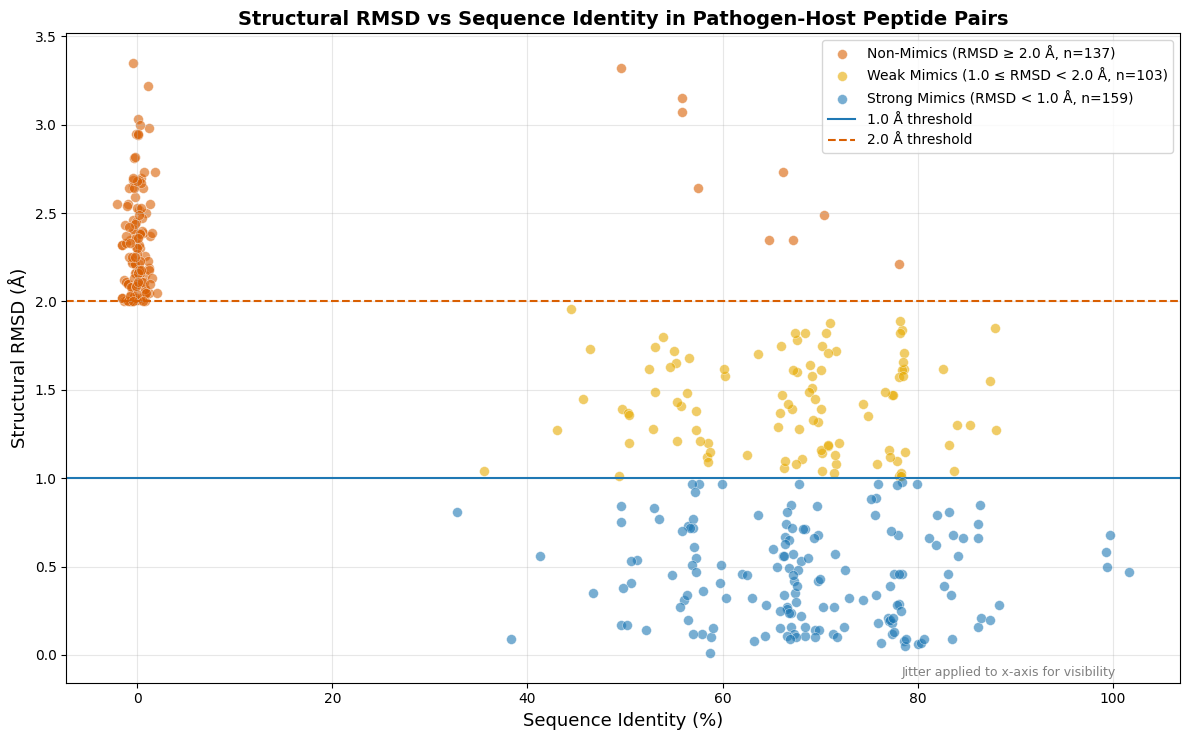

Figure 1 saved


In [38]:
# ── FIGURE 1: RMSD vs Identity scatter (three-class version) ─────────────────
np.random.seed(42)
fig, ax = plt.subplots(figsize=(12, 7.5))

for group, color, label, zorder in [
    (non_mimics,    non_color,    f'Non-Mimics (RMSD ≥ 2.0 Å, n={len(non_mimics)})',    1),
    (weak_mimics,   weak_color,   f'Weak Mimics (1.0 ≤ RMSD < 2.0 Å, n={len(weak_mimics)})',  2),
    (strong_mimics, strong_color, f'Strong Mimics (RMSD < 1.0 Å, n={len(strong_mimics)})', 3)
]:
    jitter_x = group['Identity percentage'] + np.random.normal(0, 0.8, len(group))
    ax.scatter(jitter_x, group['Structural RMSD'], color=color, alpha=0.6,
               label=label, edgecolors='white', linewidths=0.4, s=50, zorder=zorder)

ax.axhline(y=1.0, color=strong_color, linestyle='-',  linewidth=1.5, label='1.0 Å threshold')
ax.axhline(y=2.0, color=non_color,    linestyle='--', linewidth=1.5, label='2.0 Å threshold')

# Annotate the within-Y-class r value (the interpretively valid one)

ax.annotate('Jitter applied to x-axis for visibility', xy=(0.75, 0.01),
            xycoords='axes fraction', fontsize=9, color='gray')

ax.set_xlabel('Sequence Identity (%)', fontsize=13)
ax.set_ylabel('Structural RMSD (Å)', fontsize=13)
ax.set_title('Structural RMSD vs Sequence Identity in Pathogen-Host Peptide Pairs',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure1_rmsd_vs_identity.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 1 saved')

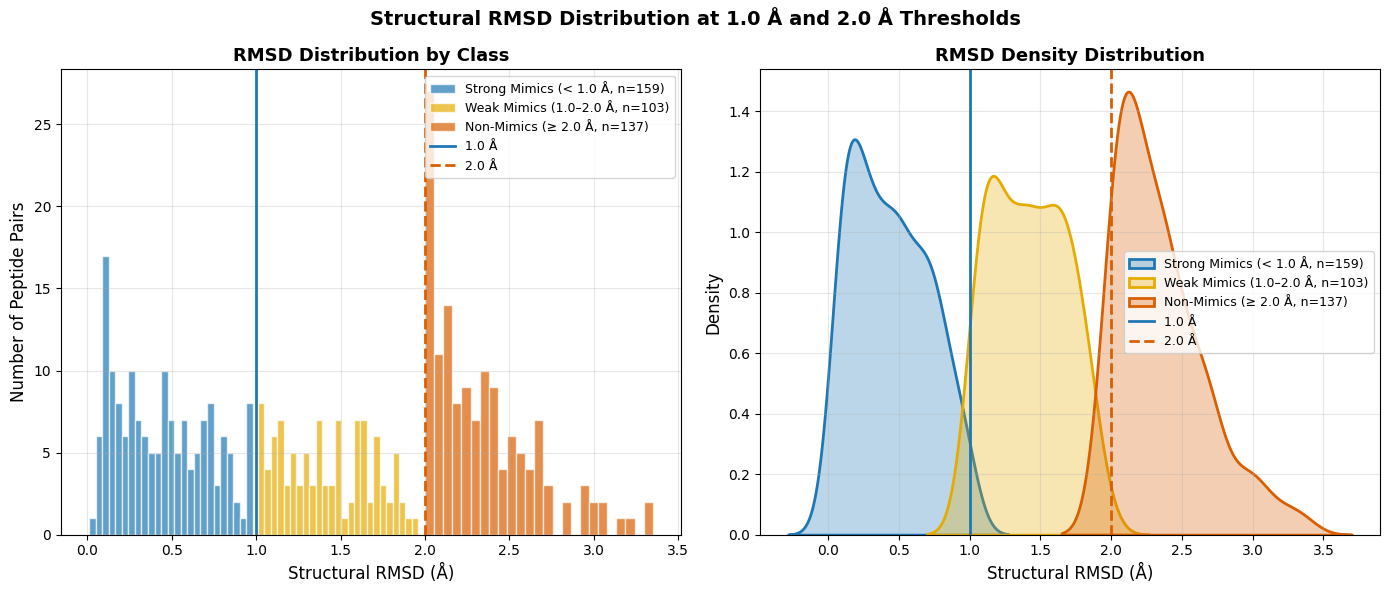

Figure 2 saved


In [39]:
# ── FIGURE 2: RMSD distribution — three classes ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for group, color, label in [
    (strong_mimics, strong_color, f'Strong Mimics (< 1.0 Å, n={len(strong_mimics)})'),
    (weak_mimics,   weak_color,   f'Weak Mimics (1.0–2.0 Å, n={len(weak_mimics)})'),
    (non_mimics,    non_color,    f'Non-Mimics (≥ 2.0 Å, n={len(non_mimics)})')
]:
    axes[0].hist(group['Structural RMSD'].dropna(), bins=25, color=color,
                 alpha=0.7, label=label, edgecolor='white', linewidth=1)
    sns.kdeplot(data=group['Structural RMSD'].dropna(), ax=axes[1],
                color=color, fill=True, alpha=0.3, linewidth=2, label=label)

for ax in axes:
    ax.axvline(x=1.0, color=strong_color, linestyle='-',  linewidth=2, label='1.0 Å')
    ax.axvline(x=2.0, color=non_color,    linestyle='--', linewidth=2, label='2.0 Å')
    ax.set_xlabel('Structural RMSD (Å)', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Number of Peptide Pairs', fontsize=12)
axes[0].set_title('RMSD Distribution by Class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('RMSD Density Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Structural RMSD Distribution at 1.0 Å and 2.0 Å Thresholds',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figure2_rmsd_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 2 saved')

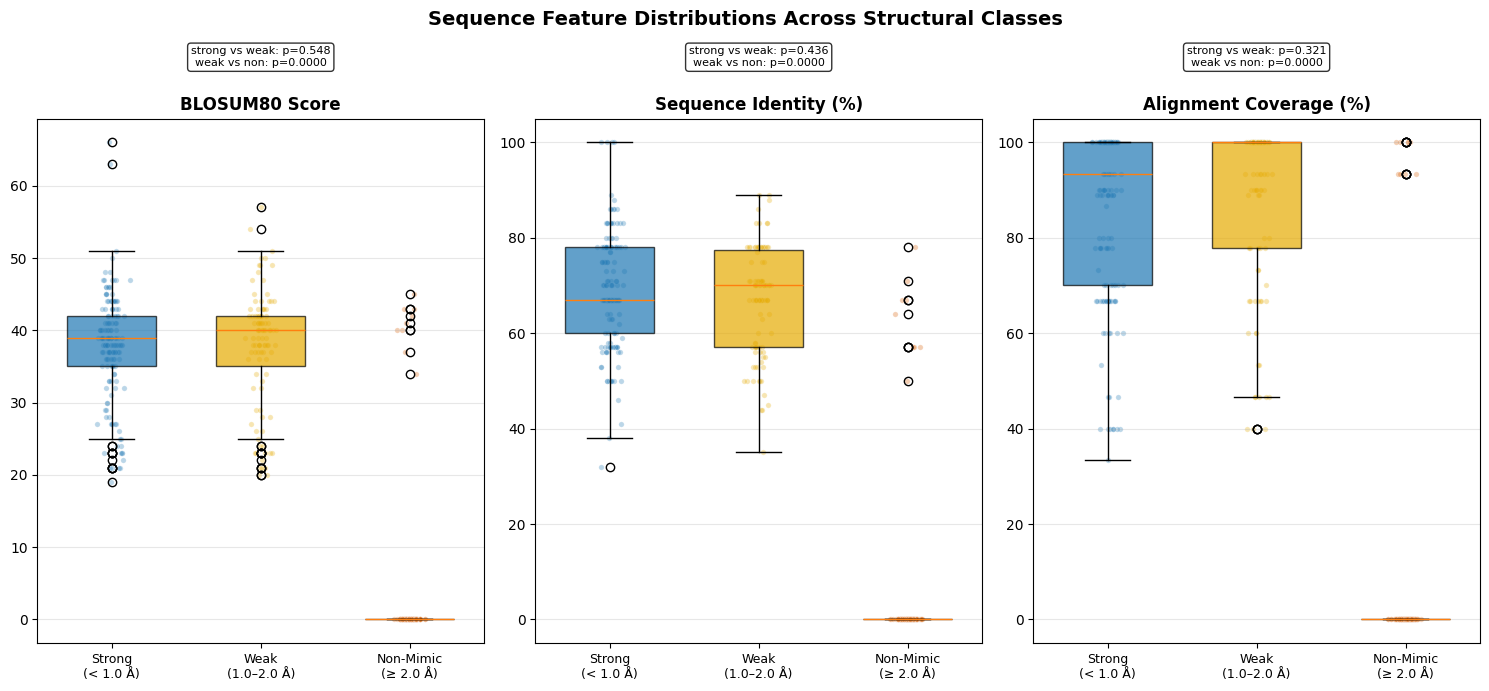

Figure 3 saved


In [40]:
# ── FIGURE 3: Boxplots — sequence features by class ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

for i, (col, title) in enumerate([
    ('BLOSUM80 score',           'BLOSUM80 Score'),
    ('Identity percentage',      'Sequence Identity (%)'),
    ('Alignment_coverage_sequence', 'Alignment Coverage (%)')
]):
    data_by_class = [
        strong_mimics[col].dropna(),
        weak_mimics[col].dropna(),
        non_mimics[col].dropna()
    ]
    bp = axes[i].boxplot(data_by_class, patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], [strong_color, weak_color, non_color]):
        patch.set_facecolor(color); patch.set_alpha(0.7)

    # Jitter points
    for j, (data, color) in enumerate(zip(data_by_class, [strong_color, weak_color, non_color])):
        axes[i].scatter(np.random.normal(j+1, 0.04, len(data)), data,
                        alpha=0.3, s=15, color=color, edgecolors='white', linewidth=0.5)

    # p-values
    p_sw, _ = mannwhitneyu(data_by_class[0], data_by_class[1], alternative='two-sided'), None
    p_sw = mannwhitneyu(data_by_class[0], data_by_class[1], alternative='two-sided').pvalue
    p_wn = mannwhitneyu(data_by_class[1], data_by_class[2], alternative='two-sided').pvalue

    axes[i].annotate(f'strong vs weak: p={p_sw:.3f}\nweak vs non: p={p_wn:.4f}',
                     xy=(0.5, 1.1), xycoords='axes fraction', ha='center', fontsize=8,
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    axes[i].set_xticklabels(['Strong\n(< 1.0 Å)', 'Weak\n(1.0–2.0 Å)', 'Non-Mimic\n(≥ 2.0 Å)'],
                             fontsize=9)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Sequence Feature Distributions Across Structural Classes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figure3_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 3 saved')

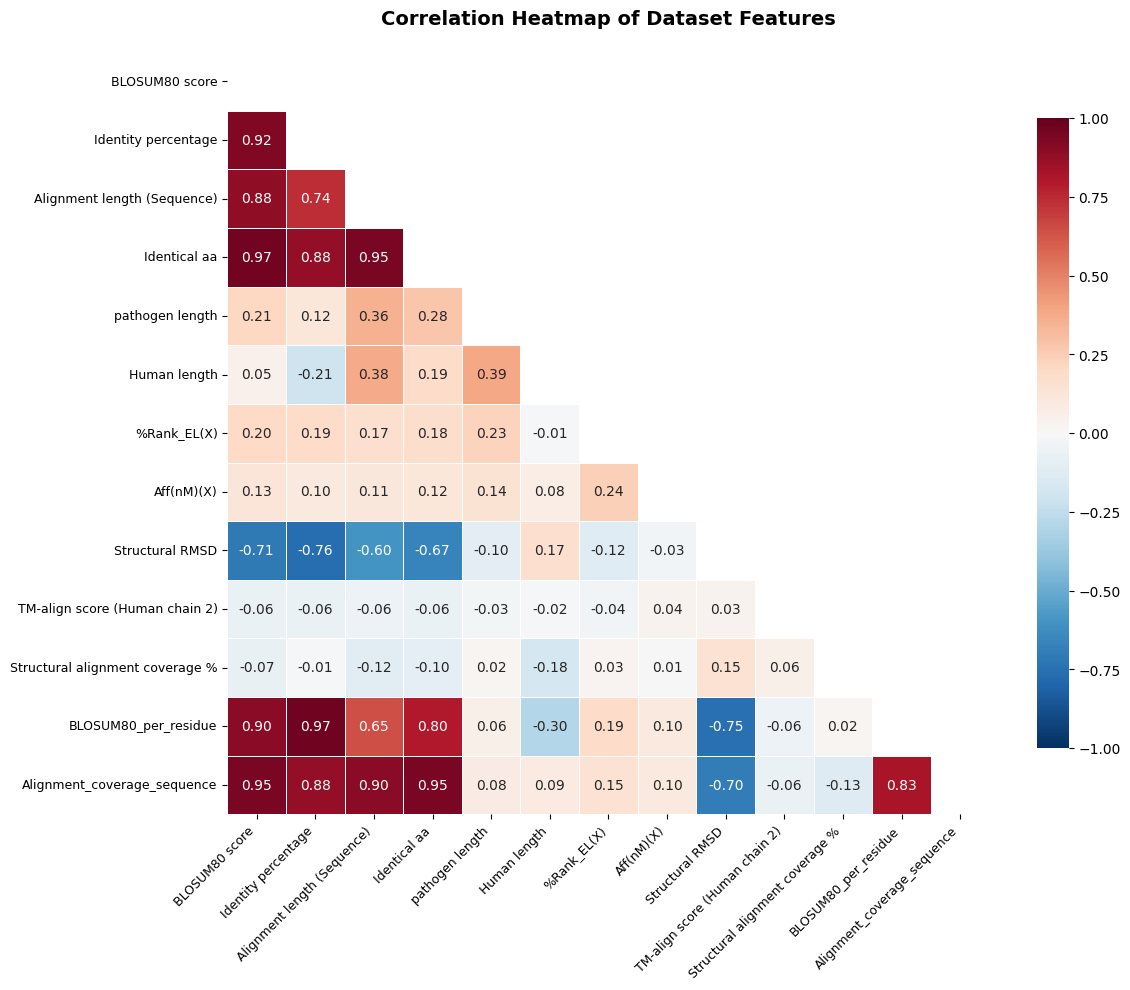

Figure 4 saved


In [41]:
# ── FIGURE 4: Correlation heatmap ────────────────────────────────────────────
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Dataset Features', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('figure4_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 4 saved')

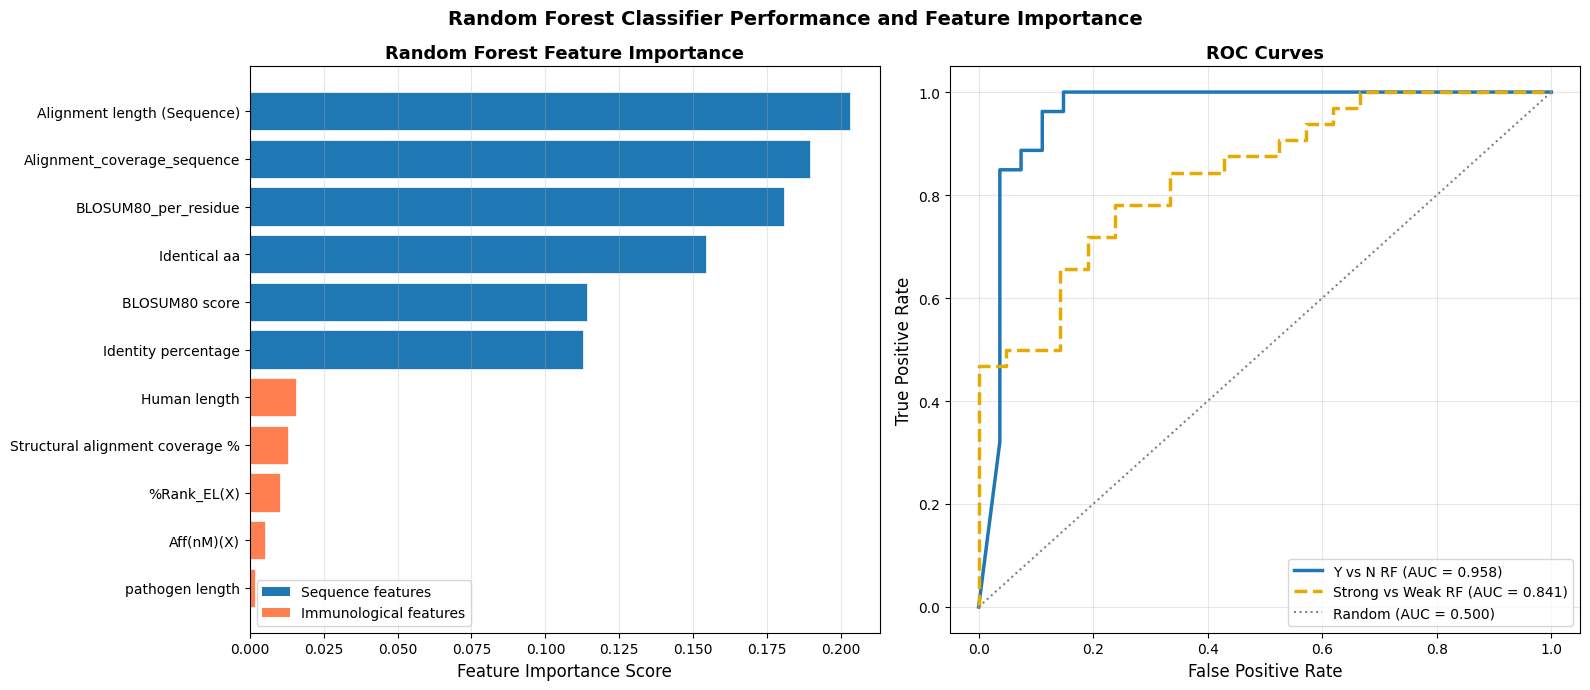

Figure 5 saved


In [42]:
# ── FIGURE 5: Feature importance + ROC curve (original RF) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

imp_df = pd.DataFrame({'Feature': FEATURES,
                        'Importance': rf_model.feature_importances_}).sort_values('Importance')
seq_feat_list = ['BLOSUM80 score', 'Identity percentage', 'Alignment length (Sequence)',
                 'Identical aa', 'BLOSUM80_per_residue', 'Alignment_coverage_sequence']
colors_bar = [strong_color if f in seq_feat_list else 'coral' for f in imp_df['Feature']]

axes[0].barh(imp_df['Feature'], imp_df['Importance'], color=colors_bar,
              edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Feature Importance Score', fontsize=12)
axes[0].set_title('Random Forest Feature Importance', fontsize=13, fontweight='bold')
axes[0].legend(handles=[
    Patch(facecolor=strong_color, label='Sequence features'),
    Patch(facecolor='coral', label='Immunological features')
], fontsize=10)
axes[0].grid(True, alpha=0.3, axis='x')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color=strong_color, linewidth=2.5,
              label=f'Y vs N RF (AUC = {auc:.3f})')
fpr_sw, tpr_sw, _ = roc_curve(y_sw_test, y_sw_proba)
axes[1].plot(fpr_sw, tpr_sw, color=weak_color, linewidth=2.5, linestyle='--',
              label=f'Strong vs Weak RF (AUC = {auc_sw:.3f})')
axes[1].plot([0,1],[0,1], color='gray', linestyle=':', linewidth=1.5, label='Random (AUC = 0.500)')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Random Forest Classifier Performance and Feature Importance',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figure5_rf_performance.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 5 saved')

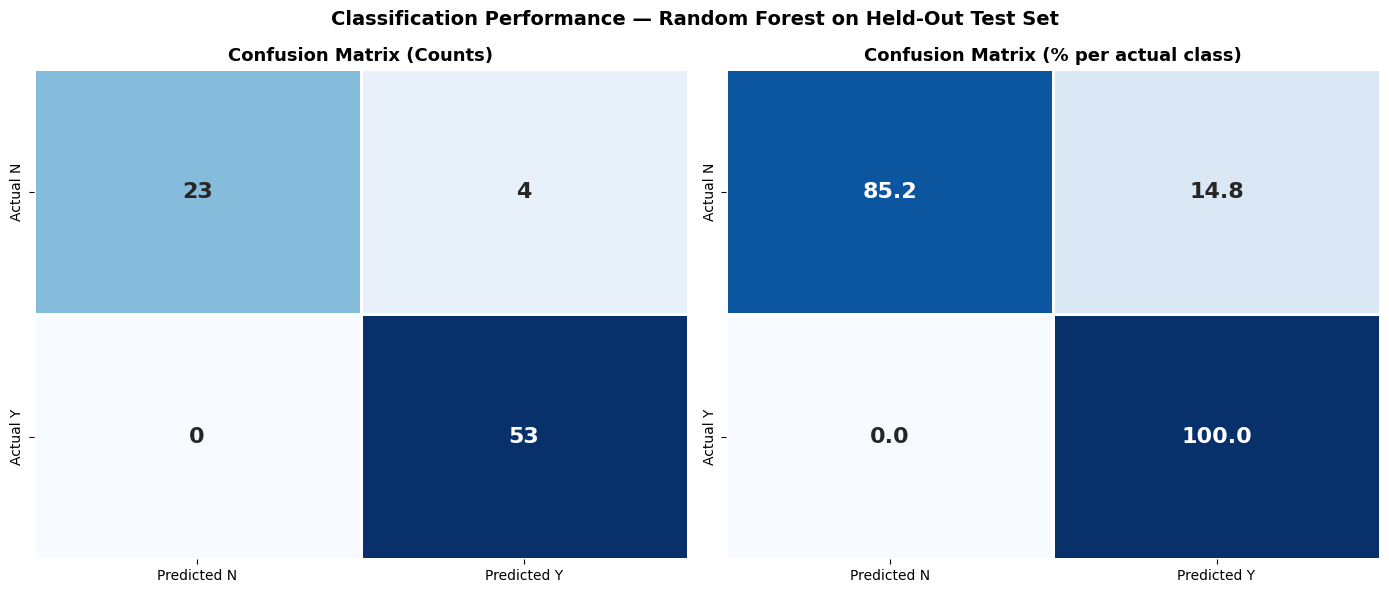

Figure 6 saved


In [43]:
# ── FIGURE 6: Confusion matrix (original RF) ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted N', 'Predicted Y'],
            yticklabels=['Actual N', 'Actual Y'],
            linewidths=2, linecolor='white', ax=axes[0], cbar=False,
            annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')

# Percentage normalised
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Predicted N', 'Predicted Y'],
            yticklabels=['Actual N', 'Actual Y'],
            linewidths=2, linecolor='white', ax=axes[1], cbar=False,
            annot_kws={'size': 16, 'weight': 'bold'})
axes[1].set_title('Confusion Matrix (% per actual class)', fontsize=13, fontweight='bold')

plt.suptitle('Classification Performance — Random Forest on Held-Out Test Set',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figure6_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 6 saved')